# Data Analysis for Physics and Astronomy
## Sommersemster 2024 
# Assignment 1

Due: **10:00 30. April 2024**

Discussion: **12:00 30. April 2024**

**Online submission** at via github classroom  

# 1. Sampling [70 points]

The Behavioral Risk Factor Surveillance System (BRFSS) is an annual telephone survey of 350,000 people in the United States. As its
name implies, the BRFSS is designed to identify risk factors in the adult population and report emerging health trends. For example,
respondents are asked about their diet and weekly physical activity, their HIV/AIDS status, possible tobacco use, and even their level of
healthcare coverage. The BRFSS Web site (http://www.cdc.gov/brfss) contains a complete description of the survey, including the research
questions that motivate the study and many interesting results derived from the data.

In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt

## Visually inspect the ASCII data file from the Data/ directory
The data file is zipped: `cdbrfss1999.zip`. Unzip it and look at it. It is in ASCII format.

The file `Codebook99.rtf` contains a detailed explanation of the individual data entries. Use the
Cookbook to understand the data columns that you are working on in this problem.

## Large data

The dataset contains 159989 entries.

**a.** Take a sample of 30000 from this dataset and export it to an ASCII file. Make sure that your method allows to draw more than one sample from the population. **[10 points]**

In [2]:
# TODO: import the file cdbrfss1999.csv with the Pandas command pd.read_csv . This creates the DataFrame cdbrfss. You can read directly from the zip file with the compression='zip' option.
cdbrfss = pd.read_csv("Data/cdbrfss1999.zip", compression='zip', low_memory=False)  # I get a mixed datatype warning without low_memory=False. I think that's because of the header.

Look up the `DataFrame.sample()` method here: [DOCUMENTATION](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sample.html#pandas.DataFrame.sample)

In [3]:
# TODO: Pandas DataFrames have the method .sample associated to randomly sample from the list. 
random_sample = cdbrfss.sample(30000)  # create sample
random_sample.to_csv("Data/cdbrfss1999_sample.csv")  # create outputfile

**b.** Discuss your method to do so. Is your sampling a "good sample" in the sense that it is representative for the larger "population"? **[5 points]**

I am not sure what is meant by "Make sure that your method allows to draw more than one sample from the population." As long as I do not change the original file, this should always be possible, shouldn't it?

The .sample method randomly chooses the specified number of rows from the original dataset. 30,000 corresponds to almost 20% of the dataset and is large enough that the sample can be assumed to be fairly representative. Obviously the sample could be skewed by chance, anyway. A cursory look at the resulting file suggests that this is not the case.

## Large columns

Each case in the dataset can have up to 241 variables. Each one of these variables corresponds to a question that was asked in the survey. For example, for **genhlth**, respondents were asked to evaluate their general health, responding either excellent, very good, good, fair or poor. The **exerany** variable indicates whether the respondent exercised in the past month (1) or did not (0). Likewise, **hlthplan** indicates whether the respondent had some form of health coverage (1) or did not (0). The **smoke100** variable indicates whether the respondent had smoked at least 100 cigarettes in their lifetime. The other variables record the respondent’s height in inches (**hti**) and feet (**htf**), **weight** in pounds as well as their desired weight, **wtdesire**, **age** in years, and **sex**.

**a.** Locate the columns corresponding to the variables **genhlth**, **exerany**, **htf**, **hti**, **smoke100**, **weight**, **wtdesire**, **age**, and **sex**.

Any reasonable method of isolating the columns and saving the subsample is accepted. For `pandas`, the list of column names is an attribute of the `DataFrame` object, and where columns without a column name are given the title 'Unnamed: [index]'.

In [6]:
selected_columns_only = random_sample[["GENHLTH", "EXERANY", "HTF", "HTI", "SMOKE100", "WEIGHT", "WTDESIRE", "AGE", "SEX"]]  # select columns
selected_columns_only.to_csv("Data/cdbrfss1999_selected_columns.csv")  # create outputfile

In [7]:
cdbrfss

,STATE,GEOSTR,DENSTR,PSU,RECORD,IMONTH,IDAY,IYEAR,INTVID,Unnamed: 9,...,Unnamed: 272,Unnamed: 273,Unnamed: 274,Unnamed: 275,Unnamed: 276,Unnamed: 277,Unnamed: 278,Unnamed: 279,Unnamed: 280,Unnamed: 281
0,1,1,1,10012,1,1,19,1999,40,NaN,...,1,9,1.0,1,3.0,11,2,1,1,1
1,1,1,1,10013,1,1,12,1999,33,NaN,...,1,9,2.0,1,3.0,8,1,1,1,1
2,1,1,1,10034,1,1,16,1999,45,NaN,...,1,9,1.0,1,1.0,3,1,1,1,1
3,1,1,1,10035,1,1,15,1999,45,NaN,...,1,9,1.0,1,1.0,2,1,1,1,1
4,1,1,1,10039,1,1,16,1999,0,NaN,...,1,9,1.0,1,2.0,6,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159984,72,1,1,121090,1,12,2,1999,6,NaN,...,1,9,1.0,1,2.0,4,1,2,3,1
159985,72,1,1,121094,1,12,3,1999,6,NaN,...,1,9,1.0,1,3.0,9,1,2,3,1
159986,72,1,1,121095,1,12,1,1999,6,NaN,...,1,9,1.0,1,3.0,10,2,2,3,1
159987,72,1,1,121097,1,12,6,1999,6,NaN,...,2,9,3.0,1,1.0,3,1,2,3,1


In [8]:
cdbrfss.columns

Index(['STATE', 'GEOSTR', 'DENSTR', 'PSU', 'RECORD', 'IMONTH ', 'IDAY ',
       'IYEAR ', 'INTVID ', 'Unnamed: 9',
       ...
       'Unnamed: 272', 'Unnamed: 273', 'Unnamed: 274', 'Unnamed: 275',
       'Unnamed: 276', 'Unnamed: 277', 'Unnamed: 278', 'Unnamed: 279',
       'Unnamed: 280', 'Unnamed: 281'],
      dtype='object', length=282)

In [9]:
cdbrfss.columns.values

array(['STATE', 'GEOSTR', 'DENSTR', 'PSU', 'RECORD', 'IMONTH ', 'IDAY ',
       'IYEAR ', 'INTVID ', 'Unnamed: 9', 'DISPCODE', 'WINDDOWN', 'SEQNO',
       'NATTMPTS', 'NRECSEL', 'NRECSTR', 'BPSELWT', 'WAKSS1S2',
       'NUMADULT', 'NUMMEN', 'NUMWOMEN', 'GENHLTH', 'PHYSHLTH',
       'MENTHLTH', 'POORHLTH', 'HLTHPLAN', 'MEDICAR2', 'TYPCOVR1',
       'TYPCOVR2', 'NOCOV12', 'PASTPLAN', 'MEDCOST', 'CHECKUP', 'BPTAKE',
       'BPHIGH', 'HIGHGT1', 'BLOODCHO', 'CHOLCHK', 'TOLDHI', 'DIABETES',
       'LASTDEN2', 'RMVTEETH', 'DENCLEAN', 'SUNBURN', 'NUMBURN',
       'SMOKE100', 'SMOKEDAY', 'SMOKENUM', 'SMOKNM30', 'STOPSMOK',
       'LASTSMOK', 'DRINKANY', 'ALCOHOL', 'NALCOCC', 'DRINKGE5',
       'DRINKDRI', 'AGE', 'ORACE', 'HISPANIC', 'MARITAL', 'CHLD04',
       'CHLD0512', 'CHLD1317', 'EDUCA', 'EMPLOY', 'INCOME2', 'WEIGHT',
       'HTF', 'HTI', 'CTYCODE', 'NUMHHOLD', 'NUMPHONS', 'SEX', 'HADMAM',
       'HOWLONG', 'WHYDONE', 'PROFEXAM', 'LENGEXAM', 'REASEXAM', 'HADPAP',
       'LASTPAP', 'WHYPAP'

In [10]:
# TODO: understand what the following commands do
columns = {"GENHLTH":22, "EXERANY":196, "HLTHPLAN":26, "SMOKE100":46, "HTF":68, "HTI":69, "WEIGHT":67, "WTDESIRE":210, "AGE":57, "SEX":73}
desired_column_names = [key for key, value in columns.items()]

**b.** Reduce your sample to include only these variables and export it to an ASCII file. **[2 points]**

- Use the method `DataFrame.loc` [DOCUMENTATION](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.loc.html) to select the columns you want.

- Use the method `DataFrame.to_csv` [DOCUMENTATION](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_csv.html) to export the subset to a CSV file.

How is this different from a)?

**c.** How many cases and how many variables are there in your sample? **[2 points]**

- (a) 9 cases; 30,000 variables

- (b) 8 cases; 30,000 variables

- x (c) 30,000 cases; 9 variables (actually 10 variables, the row index from the original dataset is in there, too)

- (d) 159,989 cases; 10 variables

**d.** What type of variable is **genhlth**? **[2 points]**

- (a) numerical, continuous

- (b) numerical, discrete

- (c) categorical (not ordinal)

- x (d) categorical, ordinal

**e.** What type of variable is **weight**? **[2 points]**

- x (a) numerical, continuous

 - (b) numerical, discrete

 - (c) categorical (not ordinal)

 - (d) categorical, ordinal

**f.** What type of variable is **smoke100**? **[2 points]**

 - (a) numerical, continuous
 
 - (b) numerical, discrete
 
 - x (c) categorical (not ordinal)
 
 - (d) categorical, ordinal

## One Bar chart

Take all **genhlth** entries from your sample and draw a bar chart to visualize how the cases are distributed across the possible categories. Convert the numerical encoding to their represetations, e.g. 1 -> "Excellent". Check the data cookbook for details. **[10 points]**

- You can use `DataFrame.value_counts` to return the distribution counts. [DOCUMENTATION](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.value_counts.html)

- You can use `DataFrame.plot` to easily plot a Pandas Series or DataFrame. [DOCUMENTATION](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html)

Label your axes!


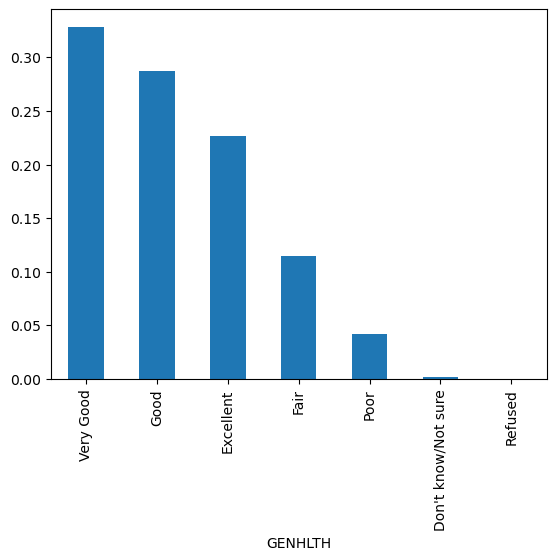

In [12]:
def genhlth_meanings(genhlth):
    if genhlth == 1:
        return "Excellent"
    if genhlth == 2:
        return "Very Good"
    if genhlth == 3:
        return "Good"
    if genhlth == 4:
        return "Fair"
    if genhlth == 5:
        return "Poor"
    if genhlth == 7:
        return "Don't know/Not sure"
    if genhlth == 9:
        return "Refused"

genhlth_text = selected_columns_only["GENHLTH"].apply(genhlth_meanings)


genhlth_distribution_total = genhlth_text.value_counts("GENHLTH")

genhlth_distribution_total.plot(kind="bar")

plt.show()


## Two Bar Charts

Combine the **smoke100** with the **genhlth** entries from your sample and draw __TWO__ bar charts, one showing the health of the smokers and a second one showing the health of the non-smokers. **[15 points]**

## BMI

Next let’s consider a new variable **bmi** that doesn’t show up directly in this data set: Body Mass Index (BMI).  **[20 points]**

BMI is a weight to height ratio and can be calculated as.

$$  \mathrm{BMI} = \frac{\mathrm{weight(lb)}}{\mathrm{height(in)}^2} * 703$$

703 is the approximate conversion factor to change units to metric (meters and kilograms)
from imperial (inches and pounds). Compute the bmi for each case in your sample and add it to
the sample (e.g. as additional column). Visualize the distribution of the BMI in your sample.

**ATTENTION**: Remember, that the height was given in feet and inches separately. make sure
to compute the total height in inches! 

Look up the Cookbook definition. Note that the values in the height columns may have special values indicating invalid entries. E.g. 777 corresponds to an unknown or uincertain height in inches and 999 corresponds to a refused answer. Similar  issues arise with the height in feet numbers. Make sure to clean your data from these invalid entries. 

**HINT** You can use the `DataFrame.isin` method ( [DOCUMENTATION](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.isin.html)) together with the logical NOT operator `~` to only select contents from a list that are not in a list of values. Don't forget to convert feet to inches. The units package helps: 

In [43]:
(1 * u.imperial.foot).to(u.imperial.inch).value

12.0

# 2. Multi-Dimensional Visualization [30 Points]

There are many different possibilities to visualize data. In this exercise you should select a particular
suitable way to visualize the provided data sets. Think about what information you want to relay and
what method works best - be creative (especially for the high-dimensional data.

The directory Data/ contains all data files for this problem in CSV-format.

Here is a brief example on how to plot data from a Pandas dataframe.

In [44]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt 

Remember that Pandas allows to plot data very easily ([DOCUMENTATION](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html)):

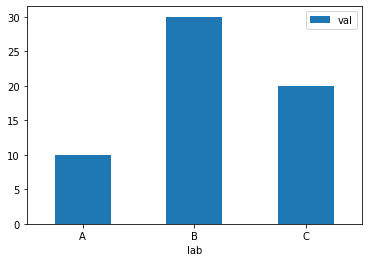

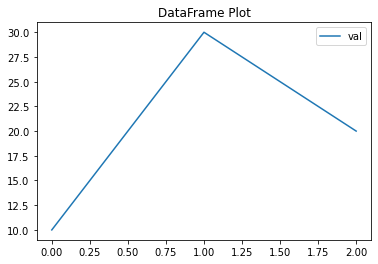

In [45]:
df = pd.DataFrame({'lab':['A', 'B', 'C'], 'val':[10, 30, 20]})

ax = df.plot(kind='bar', x='lab', y='val', rot=0)

ax = df.plot(title="DataFrame Plot")

## 1-D data

Load the data in `Data/DATA-Exercise1-1D.csv`.

Show the results of 1000 coin tosses (head "H" or tail "T").  **[5 points]**

## 2-D data

Load the data in `Data/DATA-Exercise1-2D.csv`.

Plot the world population since 10 000 B.C.  **[5 points]**

## 3-D data

Load the data in `Data/DATA-Exercise1-3D.csv`.

Display the intensity map (using the columns x, y, and intensity).  **[5 points]**

## 4-D data

Load the data in `Data/DATA-Exercise1-3D.csv`.

How will you show the volume properties (using columns x, y, z, and value)  **[5 points]**

## 5-D data

Load the data in `Data/DATA-Exercise1-4D.csv`.

Represent this table with columns "Country", "PovertyFraction", "GDPPerCapita $", "MilitaryExpenditureFraction", "Population". **[5 points]**

## 6-D data

Load the data in `Data/DATA-Exercise1-6D.csv`.

Find a way to visually represent the data (with columns x, y, z, size, val, direction angle).  **[5 points]**